In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Covid19data.xlsx to Covid19data.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("Covid19data.xlsx")

df.head()

,SNo,ObservationDate,Province/State,Region,Country,Last Update,Confirmed,Deaths,Recovered
0,1,03/22/2019,Anhui,Mainland,China,1/22/2020 17:00,1,0,0
1,2,03/24/2019,Beijing,Mainland,China,1/22/2020 17:00,14,0,0
2,3,03/25/2019,Chongqing,Mainland,China,1/22/2020 17:00,6,0,0
3,4,03/26/2019,Fujian,Mainland,China,1/22/2020 17:00,1,0,0
4,5,03/27/2019,Gansu,Mainland,China,1/22/2020 17:00,0,0,0


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 15039
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15039 entries, 0 to 15038
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   SNo              15039 non-null  int64 
 1   ObservationDate  15039 non-null  object
 2   Province/State   12263 non-null  object
 3   Region           15038 non-null  object
 4   Country          15039 non-null  object
 5   Last Update      15039 non-null  object
 6   Confirmed        15039 non-null  int64 
 7   Deaths           15039 non-null  int64 
 8   Recovered        15039 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.0+ MB


In [ ]:

df.columns = df.columns.str.strip()

df['ObservationDate'] = pd.to_datetime(
    df['ObservationDate'],
    errors='coerce'
)

df = df.dropna(subset=['Country', 'Confirmed', 'Deaths', 'Recovered'])

df = df[df['ObservationDate'].dt.year >= 2020]

df['Country'] = df['Country'].astype(str).str.strip()

print(df.shape)
df.head()

(14990, 9)


,SNo,ObservationDate,Province/State,Region,Country,Last Update,Confirmed,Deaths,Recovered
49,50,2020-01-23,Hubei,Mainland,China,1/23/20 17:00,444,17,28
50,51,2020-01-23,Heilongjiang,Mainland,China,1/23/20 17:00,2,0,0
51,52,2020-01-23,Henan,Mainland,China,1/23/20 17:00,5,0,0
52,54,2020-01-23,Hubei,Mainland,China,1/23/20 17:00,444,17,28
53,55,2020-01-23,Hunan,Mainland,China,1/23/20 17:00,9,0,0


In [ ]:
df_sorted = df.sort_values('ObservationDate')

country_date = df_sorted.groupby(
    ['Country', 'ObservationDate'],
    as_index=False
)[['Confirmed', 'Deaths', 'Recovered']].sum()

country_latest = (
    country_date
    .sort_values('ObservationDate')
    .groupby('Country', as_index=False)
    .tail(1)
)

country_latest.head()

,Country,ObservationDate,Confirmed,Deaths,Recovered
2393,South Korea,2020-01-23,1,0,0
12,Brazil,2020-01-23,0,0,0
2011,Mexico,2020-01-23,0,0,0
400,Colombia,2020-01-23,0,0,0
2394,South korea,2020-01-24,2,0,0


In [ ]:
top3_confirmed = country_latest.nlargest(3, 'Confirmed')

print(top3_confirmed[['Country', 'Confirmed']])

        Country  Confirmed
399       China      87706
2006  Macedonia      87117
1277      Korea      70212


In [ ]:
top3_deaths = country_latest.nlargest(3, 'Deaths')

print(top3_deaths[['Country', 'Deaths']])

        Country  Deaths
399       China    4634
2006  Macedonia    2647
2386   Salvador    1437


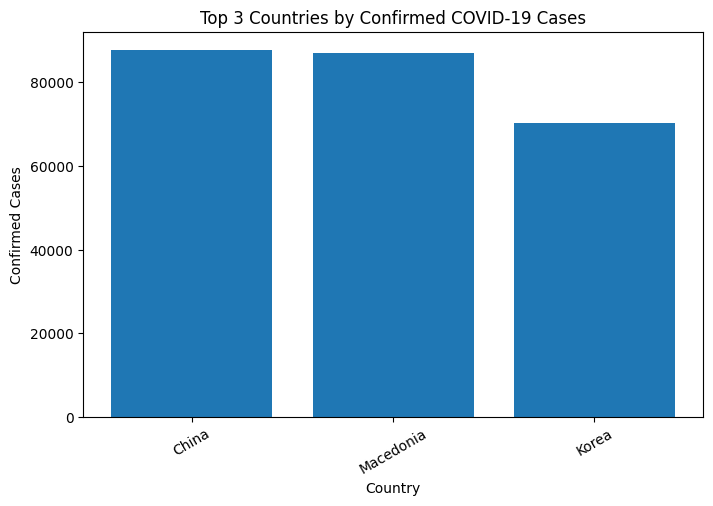

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    top3_confirmed['Country'],
    top3_confirmed['Confirmed']
)

plt.title('Top 3 Countries by Confirmed COVID-19 Cases')
plt.xlabel('Country')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=30)
plt.show()

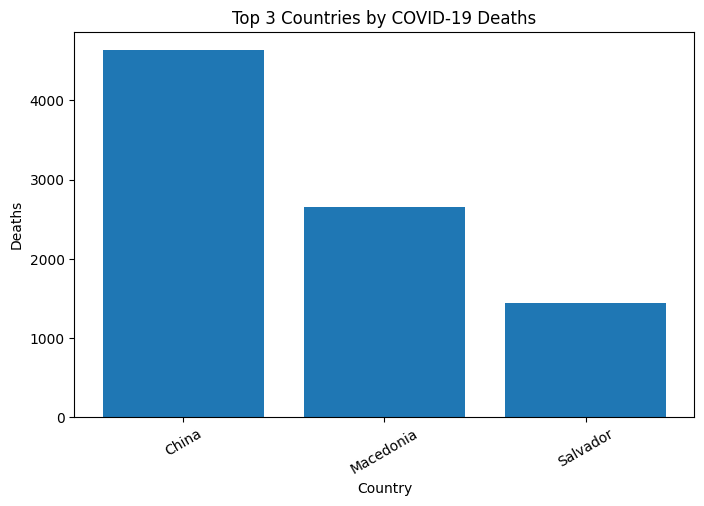

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    top3_deaths['Country'],
    top3_deaths['Deaths']
)

plt.title('Top 3 Countries by COVID-19 Deaths')
plt.xlabel('Country')
plt.ylabel('Deaths')
plt.xticks(rotation=30)
plt.show()

In [ ]:
top10_recovered = country_latest.nlargest(10, 'Recovered')

print(top10_recovered[['Country', 'Recovered']])

        Country  Recovered
399       China      82287
2006  Macedonia      68364
1277      Korea      54636
2386   Salvador      43810
1652      Lanka      42621
756      Guinea       5154
2705      Sudan       3181
3072    Zealand       2141
2027     Norway         90
2038     Panama         17


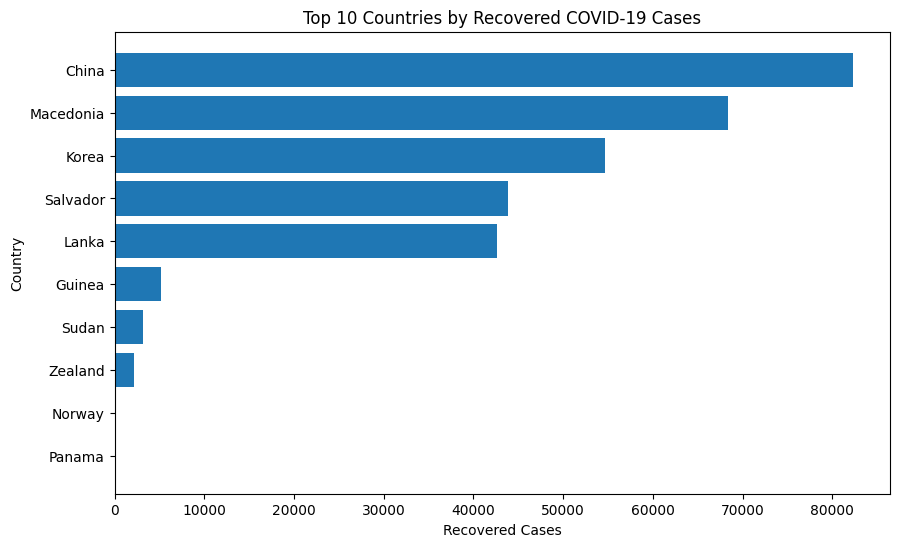

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    top10_recovered['Country'],
    top10_recovered['Recovered']
)

plt.title('Top 10 Countries by Recovered COVID-19 Cases')
plt.xlabel('Recovered Cases')
plt.ylabel('Country')
plt.gca().invert_yaxis()

plt.show()

In [ ]:
country_latest['Recovery Rate'] = np.where(
    country_latest['Confirmed'] > 0,
    (country_latest['Recovered'] / country_latest['Confirmed']) * 100,
    0
)

country_latest[
    ['Country', 'Confirmed', 'Recovered', 'Recovery Rate']
].sort_values(
    'Recovery Rate',
    ascending=False
).head(10)

,Country,Confirmed,Recovered,Recovery Rate
756,Guinea,5296,5154,97.318731
3072,Zealand,2228,2141,96.095153
399,China,87706,82287,93.821403
2386,Salvador,49539,43810,88.435374
2705,Sudan,3670,3181,86.675749
1652,Lanka,49537,42621,86.038719
2006,Macedonia,87117,68364,78.473777
1277,Korea,70212,54636,77.815758
891,Islands,21,14,66.666667
2713,Thailand,14,6,42.857143


In [ ]:
top5_recovery = country_latest[
    country_latest['Confirmed'] > 0
].nlargest(5, 'Recovery Rate')

print(
    top5_recovery[
        ['Country', 'Confirmed', 'Recovered', 'Recovery Rate']
    ]
)

       Country  Confirmed  Recovered  Recovery Rate
756     Guinea       5296       5154      97.318731
3072   Zealand       2228       2141      96.095153
399      China      87706      82287      93.821403
2386  Salvador      49539      43810      88.435374
2705     Sudan       3670       3181      86.675749


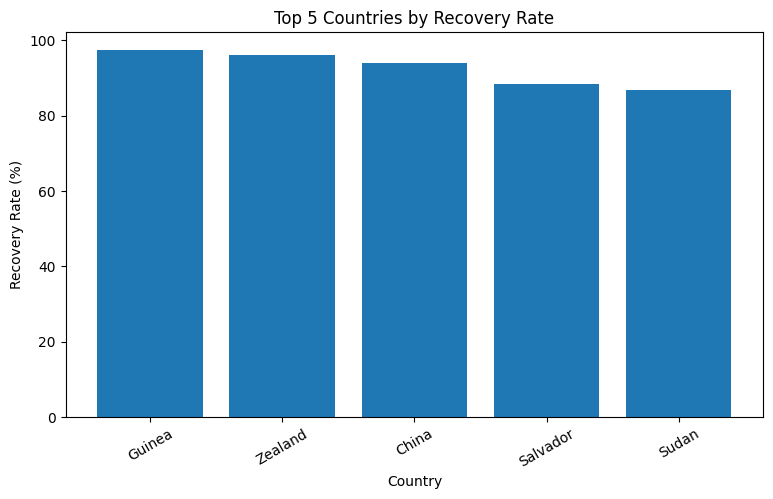

In [ ]:
plt.figure(figsize=(9,5))

plt.bar(
    top5_recovery['Country'],
    top5_recovery['Recovery Rate']
)

plt.title('Top 5 Countries by Recovery Rate')
plt.xlabel('Country')
plt.ylabel('Recovery Rate (%)')
plt.xticks(rotation=30)

plt.show()

In [ ]:
df['Month'] = df['ObservationDate'].dt.to_period('M')

In [ ]:
monthly_country = (
    df.groupby(['Month', 'Country'])[
        ['Confirmed', 'Deaths', 'Recovered']
    ].last().reset_index()
)

monthly_data = (
    monthly_country.groupby('Month')[
        ['Confirmed', 'Deaths', 'Recovered']
    ].sum().reset_index()
)

monthly_data['Month'] = monthly_data['Month'].astype(str)

monthly_data.head()

,Month,Confirmed,Deaths,Recovered
0,2020-01,173561,3732,133138
1,2020-02,175986,3779,134709
2,2020-03,178828,3819,136420
3,2020-04,181224,3862,138169
4,2020-05,183729,3909,139666


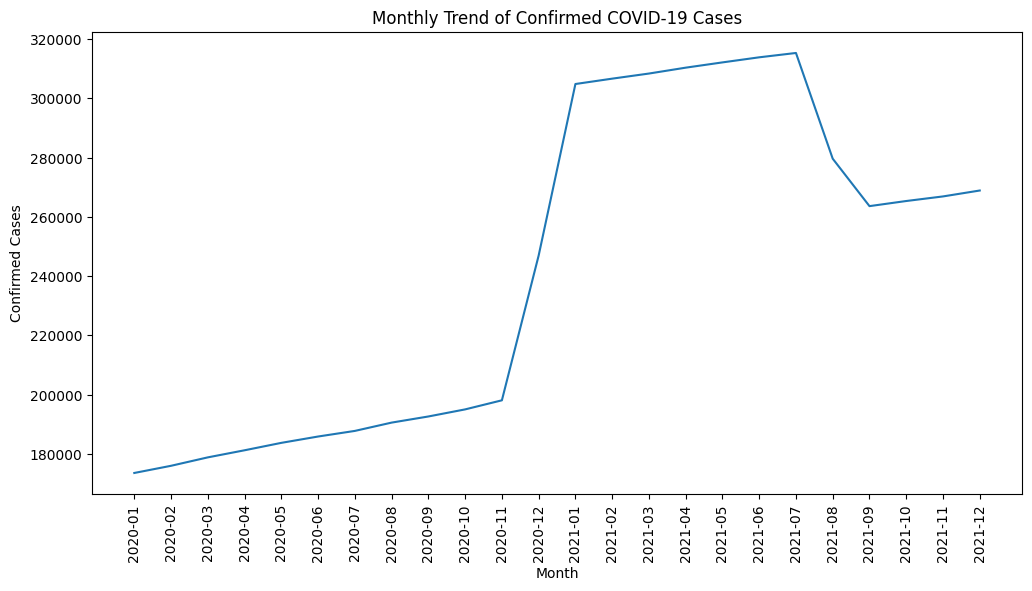

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_data['Month'],
    monthly_data['Confirmed']
)

plt.title('Monthly Trend of Confirmed COVID-19 Cases')
plt.xlabel('Month')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=90)

plt.show()

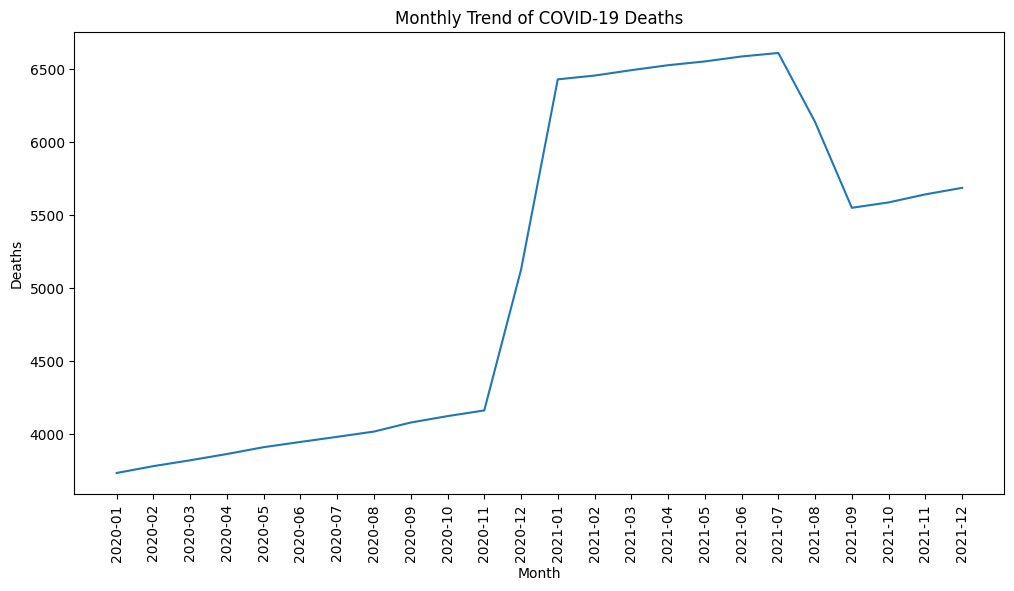

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_data['Month'],
    monthly_data['Deaths']
)

plt.title('Monthly Trend of COVID-19 Deaths')
plt.xlabel('Month')
plt.ylabel('Deaths')
plt.xticks(rotation=90)

plt.show()

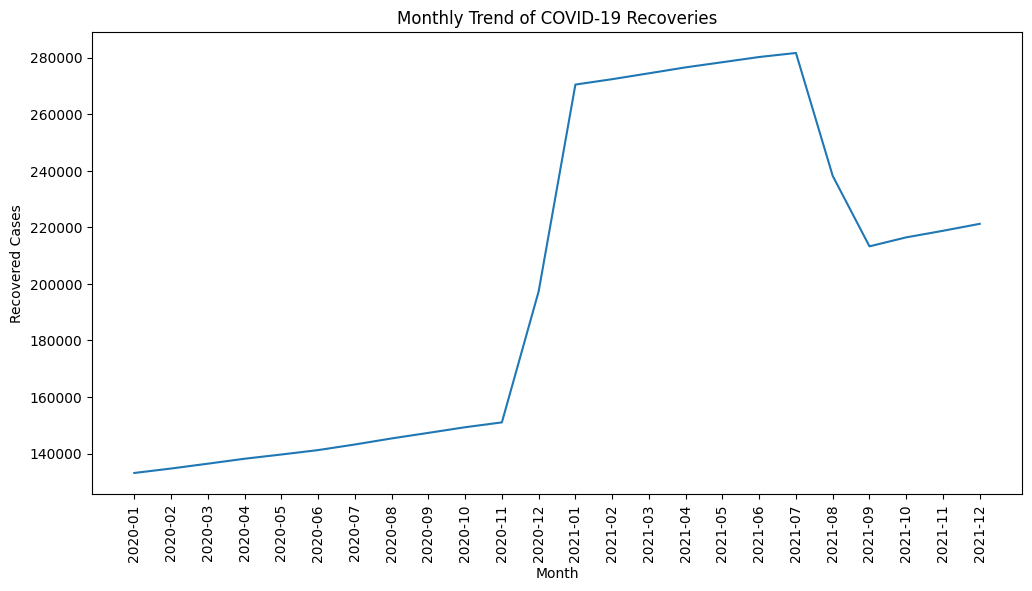

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_data['Month'],
    monthly_data['Recovered']
)

plt.title('Monthly Trend of COVID-19 Recoveries')
plt.xlabel('Month')
plt.ylabel('Recovered Cases')
plt.xticks(rotation=90)

plt.show()

In [ ]:
df['Year'] = df['ObservationDate'].dt.year

In [ ]:
year_country = (
    df.groupby(['Year', 'Country'])[
        ['Confirmed', 'Deaths', 'Recovered']
    ].last().reset_index()
)

yearly_data = (
    year_country.groupby('Year')[
        ['Confirmed', 'Deaths', 'Recovered']
    ].sum().reset_index()
)

print(yearly_data)

   Year  Confirmed  Deaths  Recovered
0  2020     247133    5126     197357
1  2021     315668    6647     283672


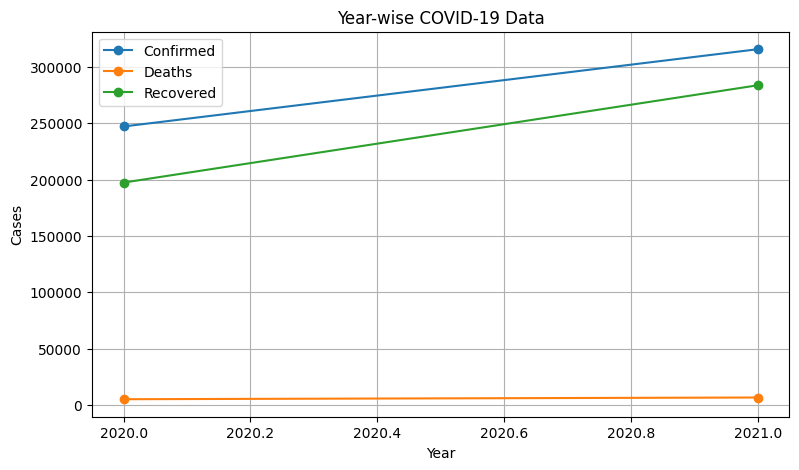

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(
    yearly_data['Year'],
    yearly_data['Confirmed'],
    marker='o',
    label='Confirmed'
)

plt.plot(
    yearly_data['Year'],
    yearly_data['Deaths'],
    marker='o',
    label='Deaths'
)

plt.plot(
    yearly_data['Year'],
    yearly_data['Recovered'],
    marker='o',
    label='Recovered'
)

plt.title('Year-wise COVID-19 Data')
plt.xlabel('Year')
plt.ylabel('Cases')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
def country_details(country_name):

    data = country_latest[
        country_latest['Country'].str.lower() ==
        country_name.lower()
    ]

    if data.empty:
        print("Country not found.")
        return

    row = data.iloc[0]

    confirmed = row['Confirmed']
    deaths = row['Deaths']
    recovered = row['Recovered']

    recovery_rate = (
        recovered / confirmed * 100
        if confirmed > 0 else 0
    )

    cfr = (
        deaths / confirmed * 100
        if confirmed > 0 else 0
    )

    print("Country:", row['Country'])
    print("Confirmed Cases:", confirmed)
    print("Deaths:", deaths)
    print("Recoveries:", recovered)
    print("Recovery Rate:", round(recovery_rate, 2), "%")
    print("Case Fatality Rate (CFR):", round(cfr, 2), "%")

In [ ]:
country_details("China")

Country: China
Confirmed Cases: 87706
Deaths: 4634
Recoveries: 82287
Recovery Rate: 93.82 %
Case Fatality Rate (CFR): 5.28 %


In [ ]:
country_details("Guinea")

Country: Guinea
Confirmed Cases: 5296
Deaths: 86
Recoveries: 5154
Recovery Rate: 97.32 %
Case Fatality Rate (CFR): 1.62 %


In [ ]:
country_details("South Korea")

Country: South Korea
Confirmed Cases: 1
Deaths: 0
Recoveries: 0
Recovery Rate: 0.0 %
Case Fatality Rate (CFR): 0.0 %


In [ ]:
def monthly_details(country_name, month):

    month_data = df[
        (df['Country'].str.lower() == country_name.lower()) &
        (df['ObservationDate'].dt.to_period('M') == month)
    ]

    if month_data.empty:
        print("Data not found for this country/month.")
        return

    latest_record = (
        month_data
        .sort_values('ObservationDate')
        .iloc[-1]
    )

    print("Country:", latest_record['Country'])
    print("Month:", month)
    print("Total Confirmed Cases:", latest_record['Confirmed'])
    print("Total Deaths:", latest_record['Deaths'])
    print("Total Recoveries:", latest_record['Recovered'])

In [ ]:
monthly_details("China", "2021-12")

Country: China
Month: 2021-12
Total Confirmed Cases: 1308
Total Deaths: 1
Total Recoveries: 1296
